Exploratory Data Analysis (EDA) and Data Preprocessing

Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv('/content/ToyotaCorolla - MLR.csv')

# Display first 5 rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


Check Dataset Information

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape:
(1436, 11)

Column Names:
Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB

Summary Statistics:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


Check Missing Values

In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


Check Duplicate Records

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


Histogram of Numerical Features

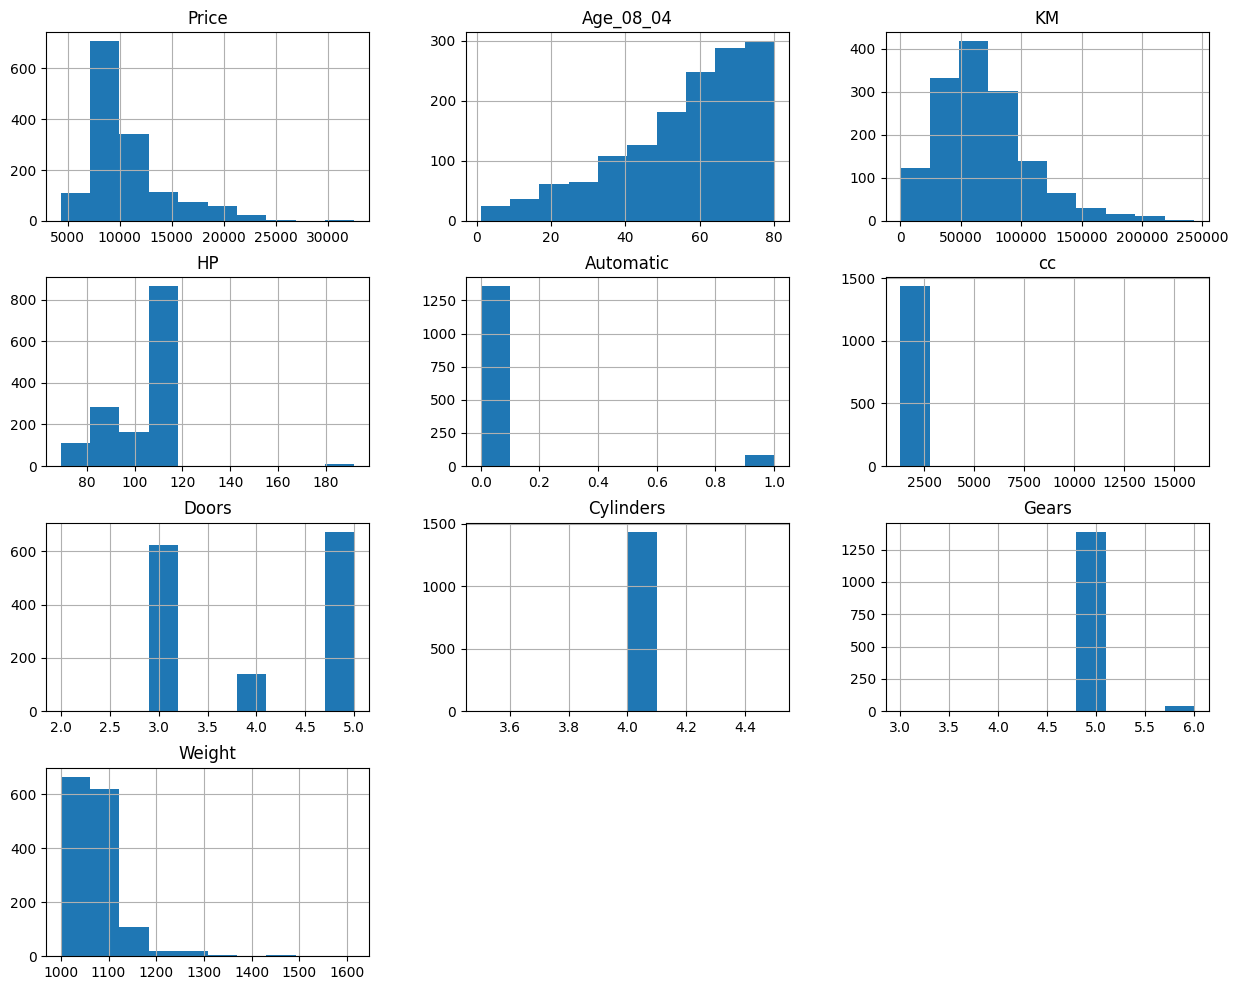

In [6]:
df.hist(figsize=(15,12))
plt.show()

Boxplots

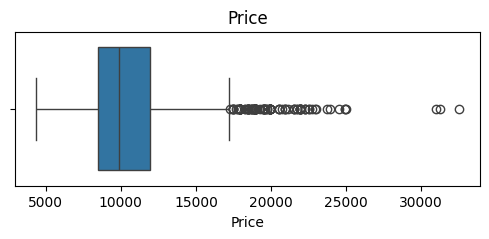

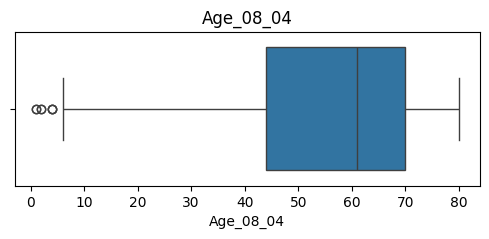

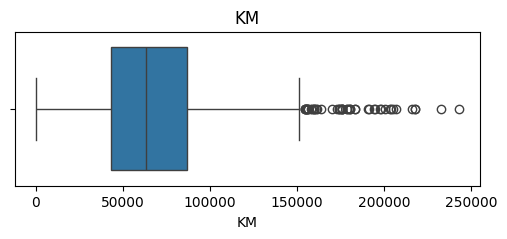

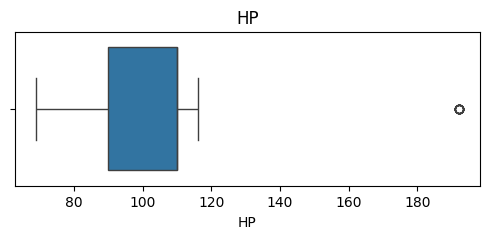

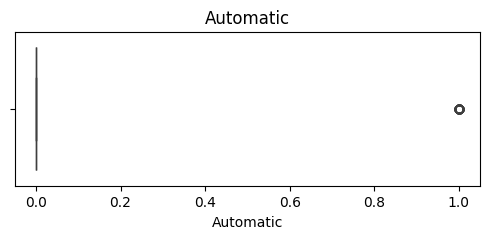

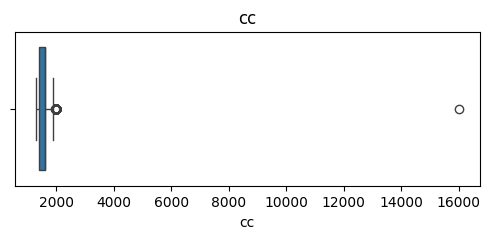

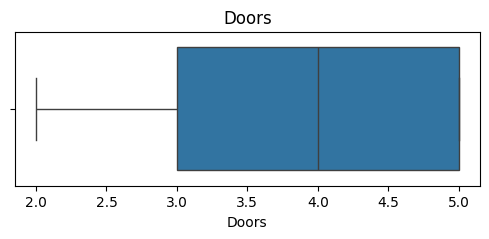

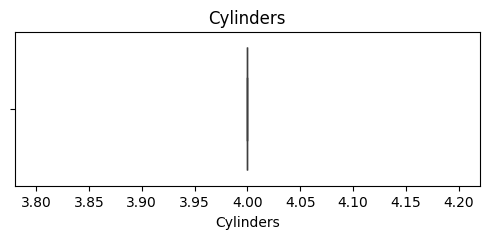

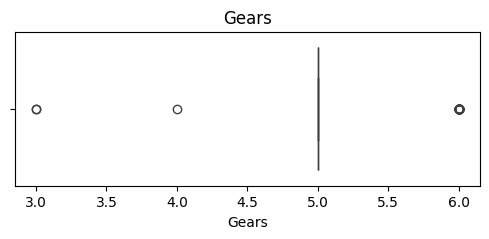

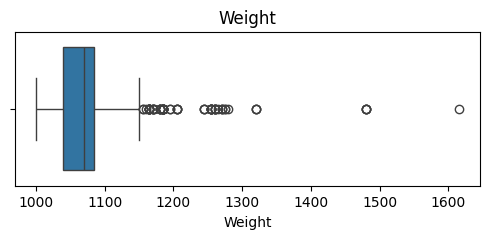

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Pair Plot


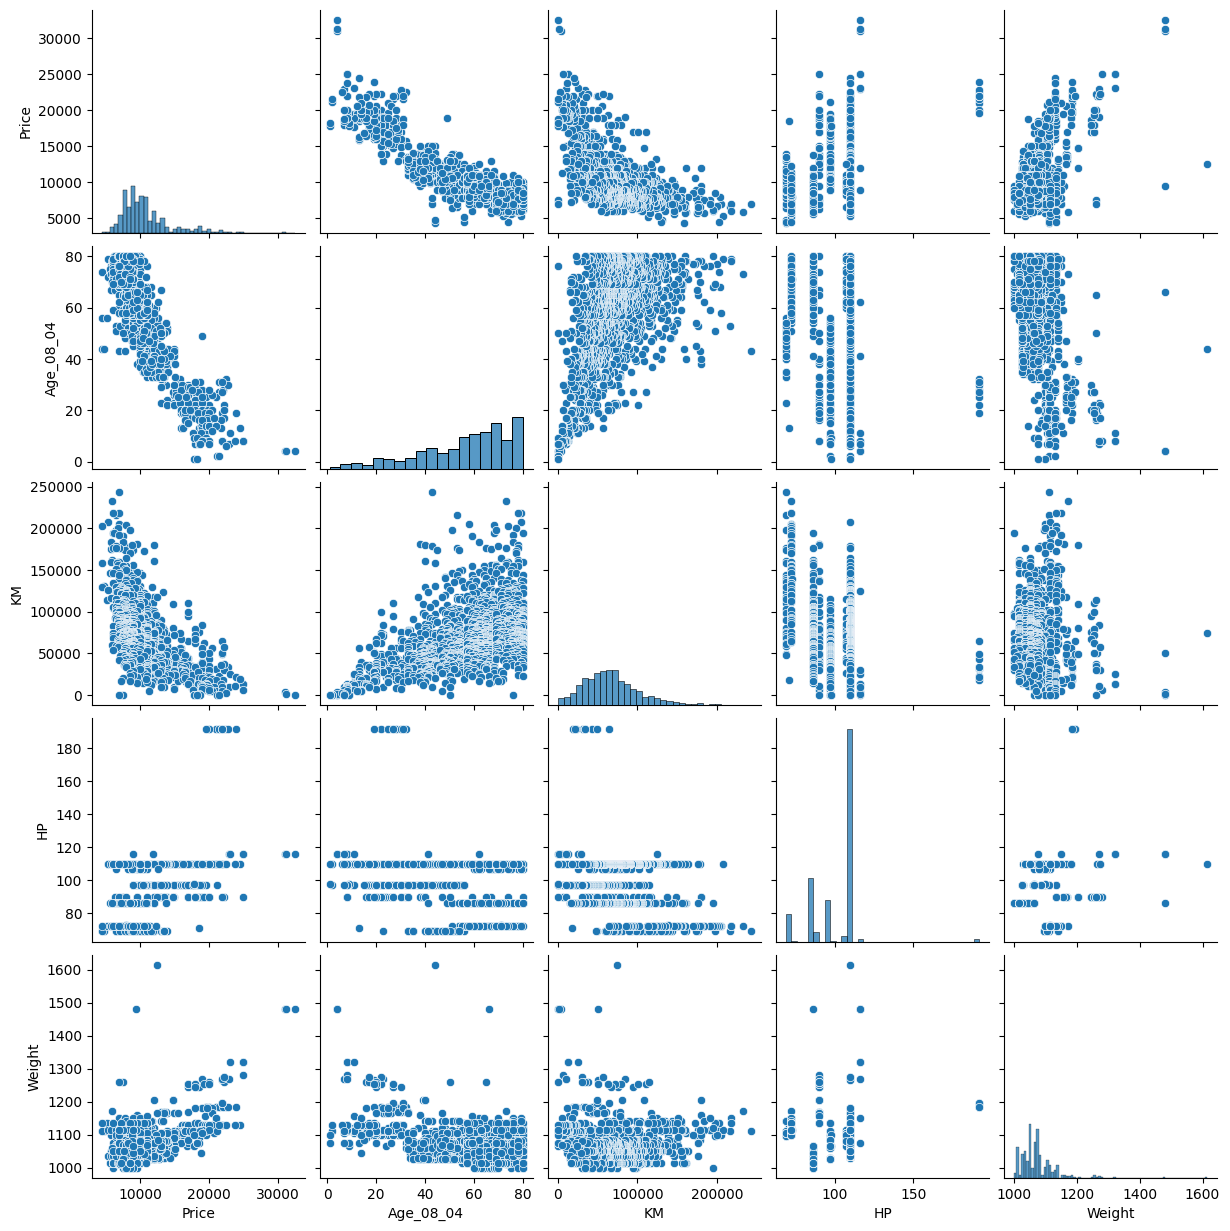

In [9]:
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

Correlation Heatmap

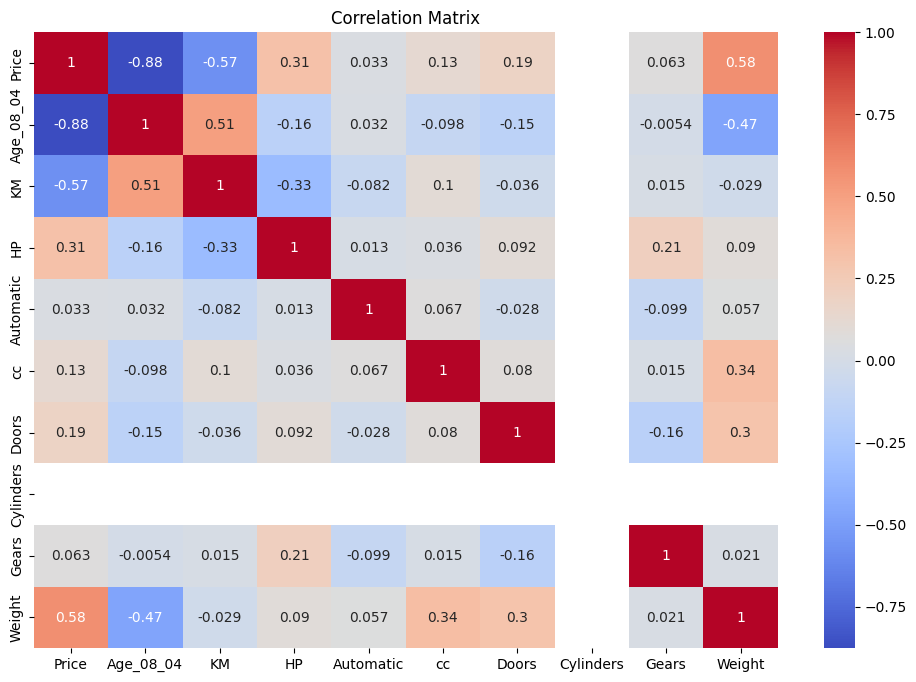

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Convert Categorical Variable

In [12]:
df = pd.get_dummies(df,
                    columns=['Fuel_Type'],
                    drop_first=True)

df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


Feature Scaling

In [13]:
X = df.drop('Price', axis=1)
y = df['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

Split the Dataset into Training and Testing Sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1148, 11)
Testing Features: (288, 11)
Training Labels: (1148,)
Testing Labels: (288,)


Build Multiple Linear Regression Models

In [15]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)
prediction1 = model1.predict(X_test)

Coefficients

In [16]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})

coef

,Feature,Coefficient
0,Age_08_04,-2.246662e+03
1,KM,-6.085706e+02
2,HP,2.102533e+02
3,Automatic,3.413608e+01
4,cc,-1.288507e+01
5,Doors,-5.743684e+01
6,Cylinders,2.842171e-13
7,Gears,1.039463e+02
8,Weight,1.362139e+03
9,Fuel_Type_Diesel,-2.127088e+01


Model 2 (Selected Features)

In [18]:
features = ['Age_08_04', 'KM', 'HP', 'Weight']

X2 = df[features]
X2 = StandardScaler().fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)
prediction2 = model2.predict(X_test2)

Model 3 (Another Feature Combination)

In [20]:
features3 = ['Age_08_04', 'KM', 'Weight']

X3 = df[features3]

X3 = StandardScaler().fit_transform(X3)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3,
    y,
    test_size=0.20,
    random_state=42
)

model3 = LinearRegression()

model3.fit(X_train3, y_train3)

prediction3 = model3.predict(X_test3)

Interpretation of Coefficients

In [21]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})

coef

,Feature,Coefficient
0,Age_08_04,-2.246662e+03
1,KM,-6.085706e+02
2,HP,2.102533e+02
3,Automatic,3.413608e+01
4,cc,-1.288507e+01
5,Doors,-5.743684e+01
6,Cylinders,2.842171e-13
7,Gears,1.039463e+02
8,Weight,1.362139e+03
9,Fuel_Type_Diesel,-2.127088e+01


Evaluate the Models

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def evaluate(actual, predicted, name):

    print("------------", name, "------------")

    print("MAE :", mean_absolute_error(actual, predicted))
    print("MSE :", mean_squared_error(actual, predicted))
    print("RMSE :", np.sqrt(mean_squared_error(actual, predicted)))
    print("R² Score :", r2_score(actual, predicted))


Evaluate Model 1

In [24]:
evaluate(y_test, prediction1, "Model 1")

------------ Model 1 ------------
MAE : 990.8872739193968
MSE : 2203043.823143705
RMSE : 1484.2654153296521
R² Score : 0.834888804061108


Evaluate Model 2

In [25]:
evaluate(y_test2, prediction2, "Model 2")

------------ Model 2 ------------
MAE : 1001.201746605583
MSE : 1993321.0129727358
RMSE : 1411.8502091131113
R² Score : 0.8506068681500834


Evaluate Model 3

In [26]:
evaluate(y_test3, prediction3, "Model 3")

------------ Model 3 ------------
MAE : 1020.5916300198207
MSE : 2234953.0617259303
RMSE : 1494.9759401829617
R² Score : 0.8324973071292439


Actual vs Predicted Plot

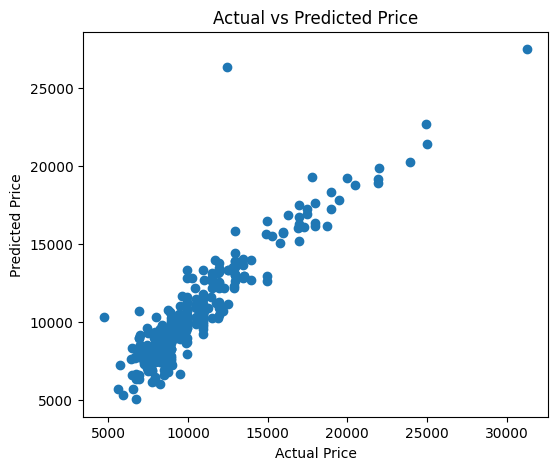

In [27]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, prediction1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

Apply Ridge and Lasso Regression

Ridge Regression

In [28]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_prediction = ridge.predict(X_test)
evaluate(y_test, ridge_prediction, "Ridge Regression")

------------ Ridge Regression ------------
MAE : 990.8667646951053
MSE : 2200682.009681124
RMSE : 1483.4695850205774
R² Score : 0.8350658145414692


Lasso Regression

In [29]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_prediction = lasso.predict(X_test)
evaluate(y_test, lasso_prediction, "Lasso Regression")

------------ Lasso Regression ------------
MAE : 990.9001017177329
MSE : 2202734.6519603888
RMSE : 1484.1612621141912
R² Score : 0.8349119754675463


Compare All Models

In [30]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Model 2",
        "Model 3",
        "Ridge",
        "Lasso"
    ],

    "R2 Score":[
        r2_score(y_test,prediction1),
        r2_score(y_test2,prediction2),
        r2_score(y_test3,prediction3),
        r2_score(y_test,ridge_prediction),
        r2_score(y_test,lasso_prediction)
    ]

})

results

,Model,R2 Score
0,Linear Regression,0.834889
1,Model 2,0.850607
2,Model 3,0.832497
3,Ridge,0.835066
4,Lasso,0.834912


Interview Questions
What is Normalization & Standardization and how is it helpful?

Normalization rescales feature values to a fixed range (typically 0 to 1) using Min-Max Scaling.
It is useful for distance-based algorithms such as KNN and Neural Networks.

Standardization transforms features to have a mean of 0 and standard deviation of 1 .
It is commonly used in Linear Regression, Logistic Regression, Ridge, Lasso, and SVM because it ensures all features contribute equally during model training.


What techniques can be used to address multicollinearity in Multiple Linear Regression?

Remove highly correlated independent variables.

Calculate and analyze the Variance Inflation Factor (VIF) to identify multicollinearity.

Use Ridge Regression to reduce coefficient variance.

Use Lasso Regression for feature selection by shrinking some coefficients to zero.

Apply Principal Component Analysis (PCA) to transform correlated variables into independent components.

Collect more data if feasible to improve model stability.